In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,mean_squared_error,r2_score)
import pickle

In [5]:
df = pd.read_csv(r"C:/Users/mysel/OneDrive/Desktop/Personal Docs/Projects/House Price Prediction/Data/train.csv")

In [11]:
print("First 5 rows of dataset")
print(df.head())

First 5 rows of dataset
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice

In [12]:
print("\nDataset Shape")
print(df.shape)


Dataset Shape
(1460, 81)


In [13]:
print("\nColumn Names")
print(df.columns)


Column Names
Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond

In [15]:
print("\nDataset Info")
print(df.info())


Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  

In [17]:
print("\nStatistical Summary")
print(df.describe())


Statistical Summary
                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1460.000000  1460.000000   1460.000000  1452.000000  1460.000000  ...   
mean      5.575342  1971.267808   1984.865753   103.685262   443.639726  ...   
std       1.112799    30.202904     20.645407   181.06

In [22]:
# STEP 4 — TARGET VARIABLE ANALYSIS

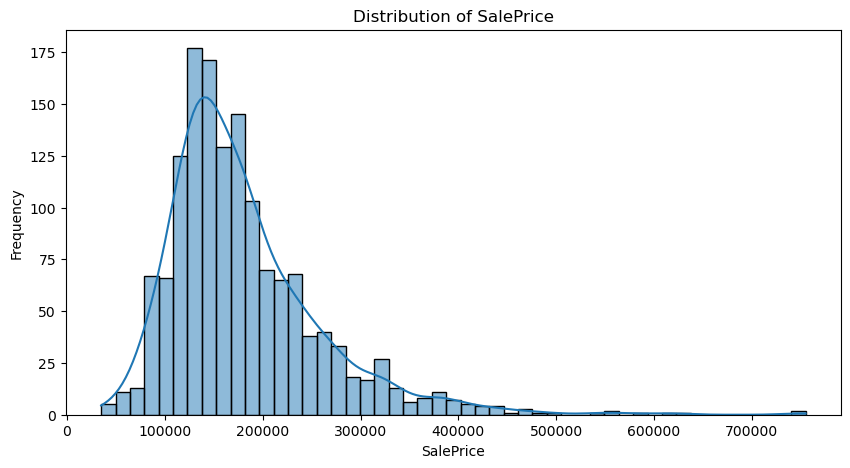

In [27]:
# Our target variable is:
# SalePrice
# Plot distribution of SalePrice
plt.figure(figsize=(10,5))

sns.histplot(df["SalePrice"],kde=True)

plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()

In [26]:
# STEP 5 — CHECK SKEWNESS

In [28]:
# Skewness tells whether data is symmetric or not

skewness = df["SalePrice"].skew()

print("\nSKEWNESS OF SALEPRICE")
print(skewness)


SKEWNESS OF SALEPRICE
1.8828757597682129


In [29]:
# STEP 6 — APPLY LOG TRANSFORMATION

In [30]:
# Why?
# House prices are usually right-skewed
# Log transformation reduces skewness

df["SalePrice"] = np.log1p(df["SalePrice"])

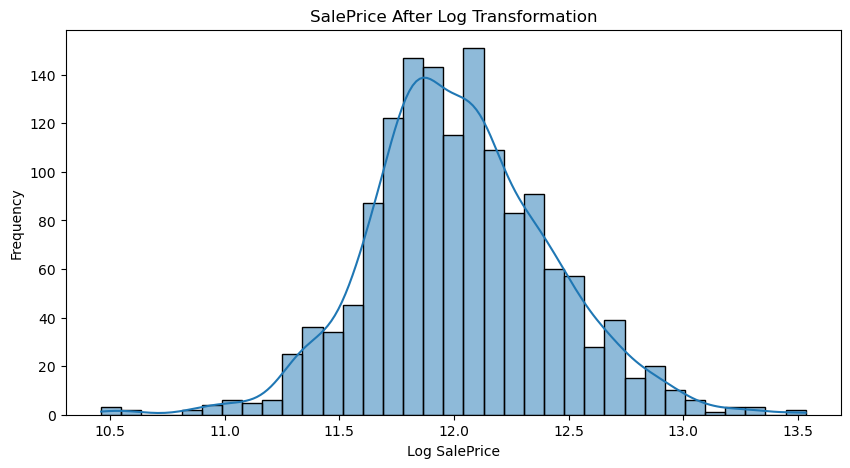

In [31]:
# Plot again after transformation

plt.figure(figsize=(10, 5))

sns.histplot(df["SalePrice"], kde=True)

plt.title("SalePrice After Log Transformation")
plt.xlabel("Log SalePrice")
plt.ylabel("Frequency")
plt.show()

In [32]:
# STEP 7 — MISSING VALUE ANALYSIS

In [37]:
# Check missing values in each column

missing_values = df.isnull().sum()
# Keep only columns with missing values

missing_values = missing_values[missing_values > 0]

# Sort missing values descending

missing_values = missing_values.sort_values(ascending=False)

print("\nMISSING VALUES")

print(missing_values)


MISSING VALUES
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [38]:
# STEP 8 — VISUALIZE MISSING VALUES

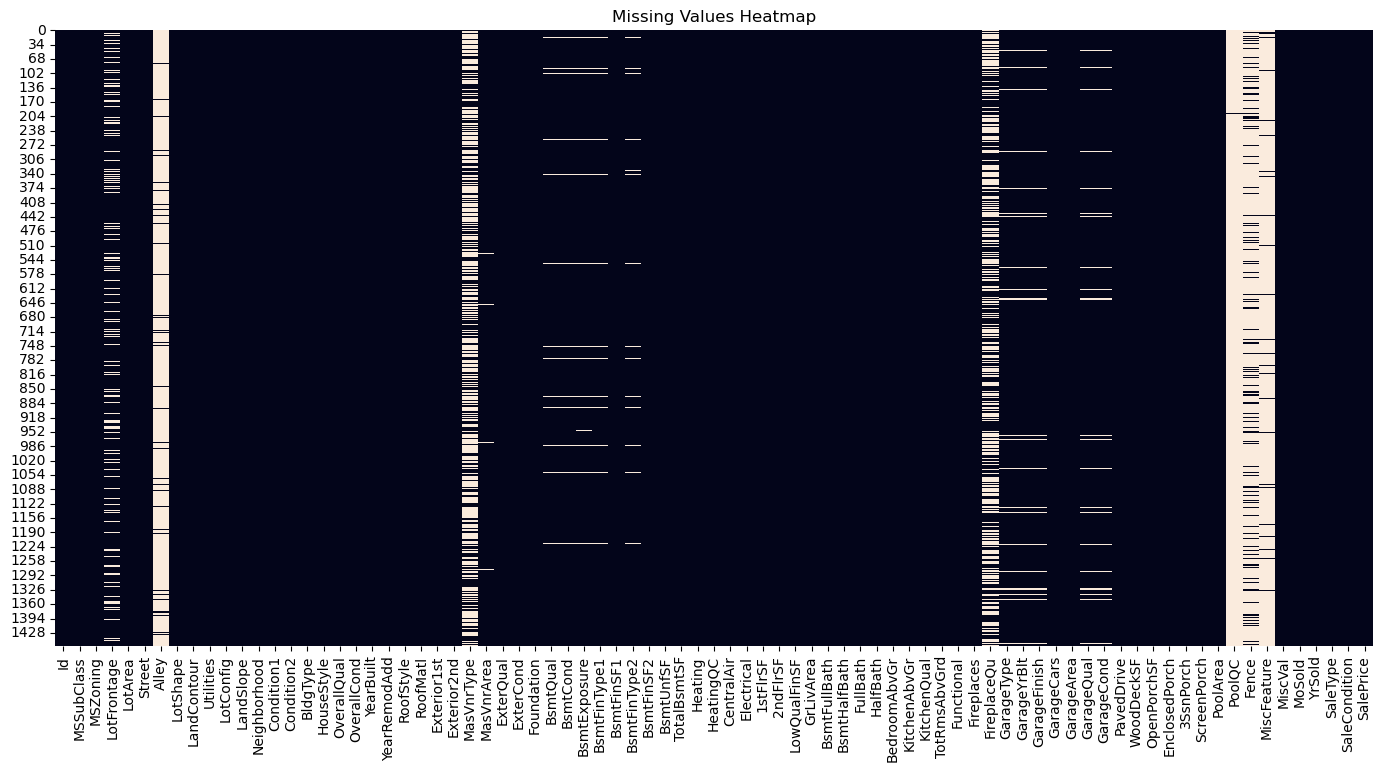

In [40]:
plt.figure(figsize=(17, 8))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.show()


In [41]:
# STEP 9 — FEATURE ENGINEERING

In [47]:

# Create new feature:
# HouseAge = YrSold - YearBuilt

df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
print("\nNEW FEATURE CREATED: HouseAge")


NEW FEATURE CREATED: HouseAge


In [48]:
# STEP 10 — HANDLE NUMERICAL MISSING VALUES

In [54]:
# Select numerical columns

num_cols = df.select_dtypes(include=np.number).columns

# Fill missing values using median

for col in num_cols:

    df[col] = df[col].fillna(df[col].median())

In [55]:
# STEP 11 — HANDLE CATEGORICAL MISSING VALUES

In [57]:
# Select categorical columns

cat_cols = df.select_dtypes(include="object").columns
# Fill missing categorical values using mode

for col in cat_cols:

    df[col].fillna(df[col].mode()[0])

In [58]:
# STEP 12 — VERIFY NO MISSING VALUES LEFT

In [59]:
print("\nTOTAL REMAINING MISSING VALUES")

print(df.isnull().sum().sum())


TOTAL REMAINING MISSING VALUES
0


In [60]:
# STEP 13 — ENCODE CATEGORICAL VARIABLES

In [61]:
# Machine learning models cannot understand text
# So we convert categories into numbers

# One Hot Encoding

df = pd.get_dummies(df, drop_first=True)

print("\nDATA AFTER ENCODING")

print(df.head())


DATA AFTER ENCODING
   Id  MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  \
0   1          60         65.0     8450            7            5       2003   
1   2          20         80.0     9600            6            8       1976   
2   3          60         68.0    11250            7            5       2001   
3   4          70         60.0     9550            7            5       1915   
4   5          60         84.0    14260            8            5       2000   

   YearRemodAdd  MasVnrArea  BsmtFinSF1  ...  SaleType_ConLI  SaleType_ConLw  \
0          2003       196.0         706  ...           False           False   
1          1976         0.0         978  ...           False           False   
2          2002       162.0         486  ...           False           False   
3          1970         0.0         216  ...           False           False   
4          2000       350.0         655  ...           False           False   

   SaleType_New  

In [62]:
# STEP 14 — CORRELATION ANALYSIS

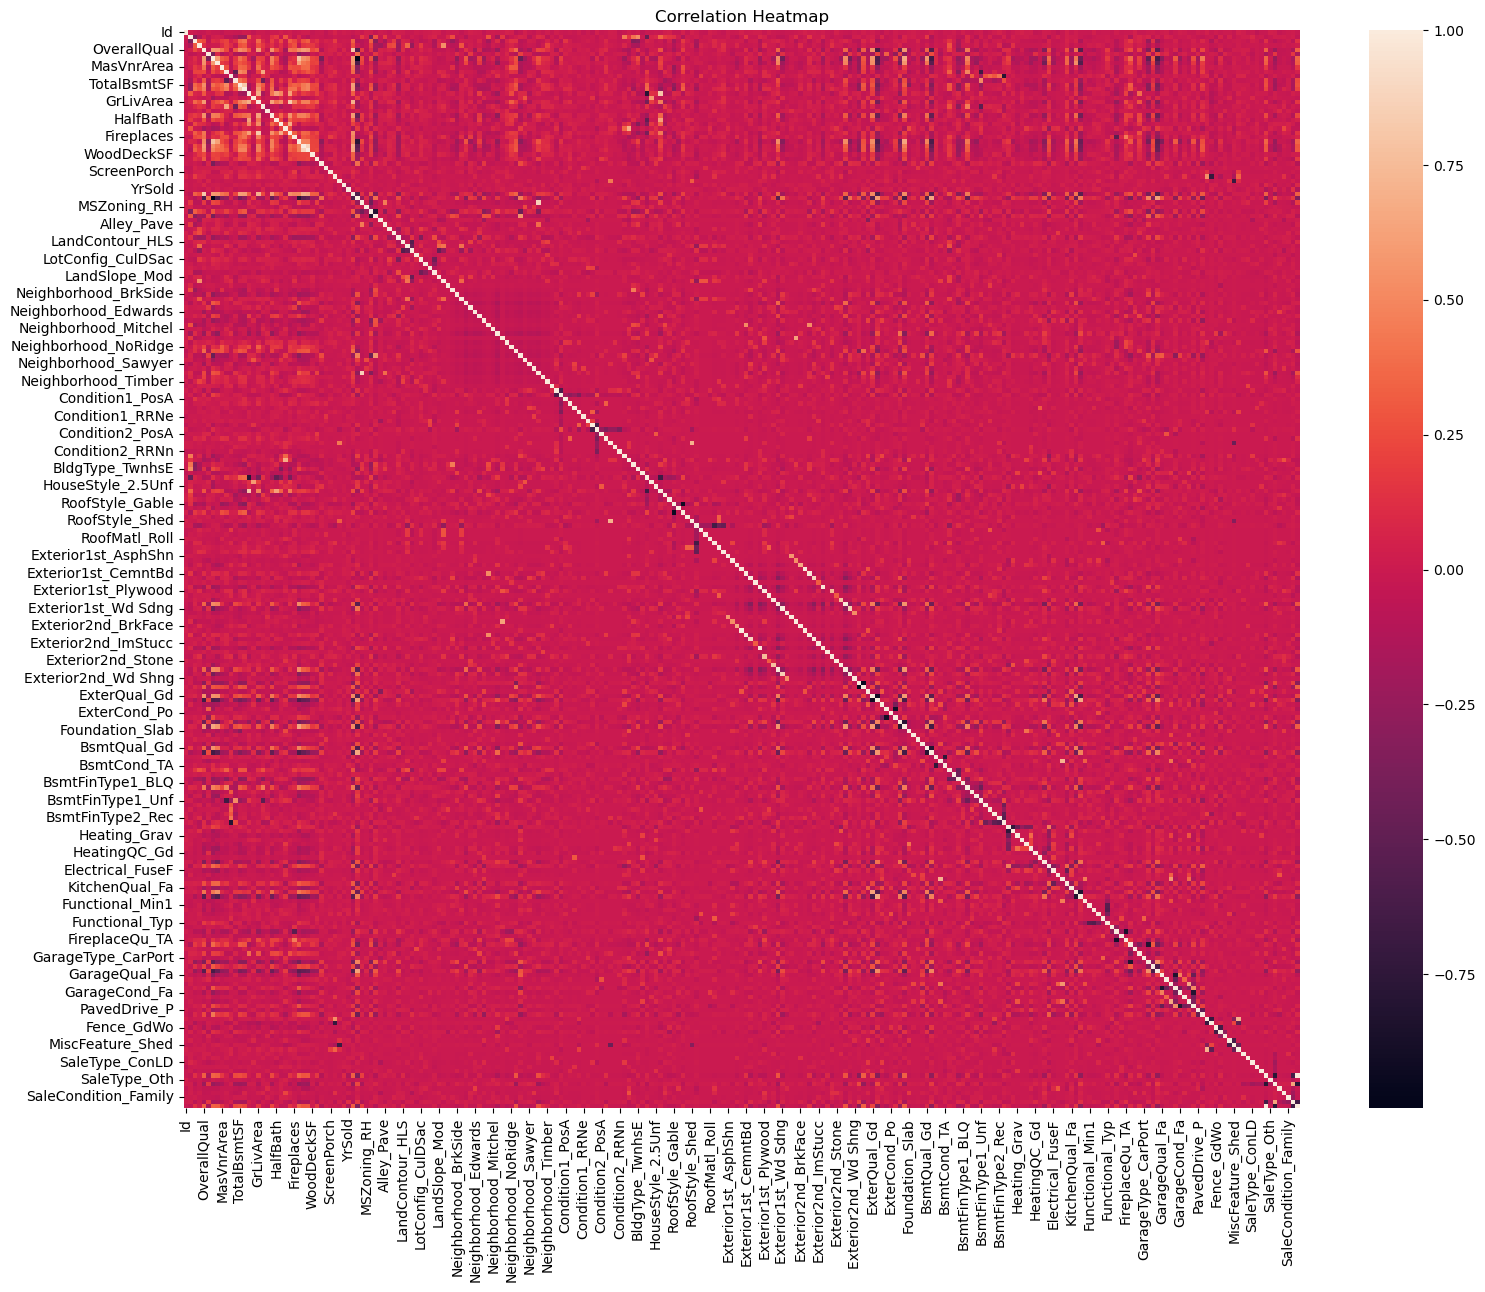

In [64]:
# Correlation measures relationship between variables
correlation_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(18, 14))

sns.heatmap(correlation_matrix)

plt.title("Correlation Heatmap")
plt.show()

In [66]:
# STEP 15 — TOP FEATURES CORRELATED WITH SALEPRICE

In [68]:
# Sort features by correlation with SalePrice
top_corr = correlation_matrix["SalePrice"].sort_values(ascending=False)
print("\nTOP FEATURES CORRELATED WITH SALEPRICE")
print(top_corr.head(15))


TOP FEATURES CORRELATED WITH SALEPRICE
SalePrice           1.000000
OverallQual         0.817185
GrLivArea           0.700927
GarageCars          0.680625
GarageArea          0.650888
TotalBsmtSF         0.612134
1stFlrSF            0.596981
FullBath            0.594771
YearBuilt           0.586570
YearRemodAdd        0.565608
TotRmsAbvGrd        0.534422
Foundation_PConc    0.530840
ExterQual_Gd        0.509675
GarageYrBlt         0.495794
Fireplaces          0.489450
Name: SalePrice, dtype: float64


In [69]:
# STEP 16 — SPLIT FEATURES AND TARGET

In [70]:
# Features (X)
# Everything except SalePrice
X = df.drop("SalePrice", axis=1)

# Target (y)
y = df["SalePrice"]

In [71]:
# STEP 17 — TRAIN TEST SPLIT

In [72]:
# Split dataset into:
# - Training data
# - Testing data
# test_size=0.2 , i.e # 20% data for testing
# Random state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [73]:
# STEP 18 — MODEL TRAINING

In [74]:
# Create Linear Regression model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

print("\nMODEL TRAINING COMPLETED")


MODEL TRAINING COMPLETED


In [75]:
# STEP 19 — MAKE PREDICTIONS

In [76]:
# Predict on test data
predictions = model.predict(X_test)

print("\nFIRST 10 PREDICTIONS")
print(predictions[:10])



FIRST 10 PREDICTIONS
[11.94055476 12.7463545  11.49729879 12.01907692 12.65158408 11.3028817
 12.43010823 11.89272883 11.24731729 11.86654309]


In [77]:
# STEP 20 — MODEL EVALUATION

In [78]:

# Mean Absolute Error
mae = mean_absolute_error(y_test, predictions)

# Mean Squared Error
mse = mean_squared_error(y_test, predictions)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# R2 Score
r2 = r2_score(y_test, predictions)

In [79]:
# STEP 21 — PRINT METRICS

In [80]:
print("\nMODEL EVALUATION")

print(f"MAE  : {mae}")
print(f"MSE  : {mse}")
print(f"RMSE : {rmse}")
print(f"R2   : {r2}")


MODEL EVALUATION
MAE  : 0.09648238718276884
MSE  : 0.04542555554889434
RMSE : 0.2131327181567728
R2   : 0.7565762022249722


In [81]:
# STEP 22 — ACTUAL VS PREDICTED VISUALIZATION

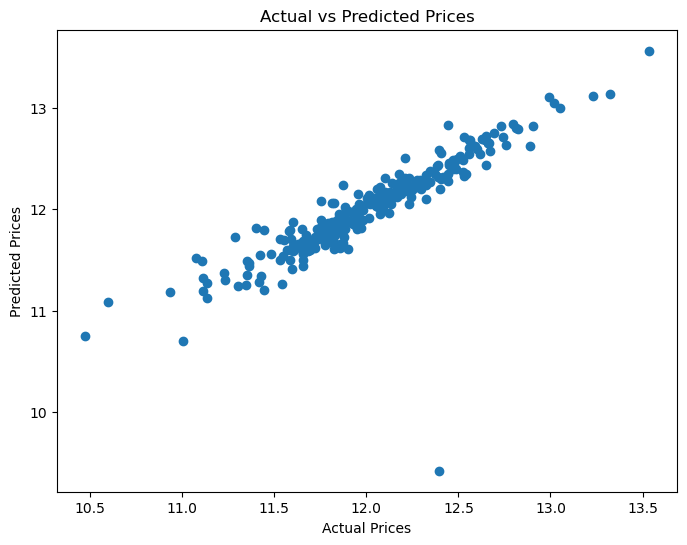

In [82]:

plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

In [83]:
# STEP 23 — SAVE TRAINED MODEL

In [88]:
# Save model inside models folder

with open("C:/Users/mysel/OneDrive/Desktop/Personal Docs/Projects/House Price Prediction/Models/house_price_model.pkl", "wb") as f:pickle.dump(model, f)

print("\nMODEL SAVED SUCCESSFULLY")


MODEL SAVED SUCCESSFULLY


In [85]:
# STEP 24 — LOAD MODEL AGAIN

In [89]:
# Demonstration of loading saved model

with open("C:/Users/mysel/OneDrive/Desktop/Personal Docs/Projects/House Price Prediction/Models/house_price_model.pkl", "rb") as f:loaded_model = pickle.load(f)

print("\nMODEL LOADED SUCCESSFULLY")


MODEL LOADED SUCCESSFULLY


In [87]:
# STEP 25 — TEST LOADED MODEL

In [90]:
sample_prediction = loaded_model.predict(X_test.iloc[:5])

print("\nPREDICTIONS FROM LOADED MODEL")
print(sample_prediction)


PREDICTIONS FROM LOADED MODEL
[11.94055476 12.7463545  11.49729879 12.01907692 12.65158408]
